# Lecture 5 companion · From batch GD to SGD and minibatches

We will fit **one line to the same four points** throughout. The model, loss, and starting parameters stay fixed; only the examples used to form each gradient change.

The story is deliberately progressive:

1. compute the exact full-data loss and gradient;
2. inspect the four individual loss surfaces;
3. take one stochastic update;
4. show why uniform one-example gradients are unbiased;
5. see why minibatch averaging keeps the mean but reduces spread; and
6. verify that one valid stochastic step can still raise the full loss.

Every random result below uses a fixed seed, so rerunning the notebook reproduces the same outputs.

In [1]:
import itertools
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

SEED = 5
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

INK, MUTED = '#23373B', '#7B8B8E'
BLUE, TEAL, ORANGE, RED = '#2B6CB0', '#2C7A7B', '#EB811B', '#D64550'
plt.rcParams.update({
    'figure.dpi': 125,
    'figure.figsize': (7.2, 3.5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': .18,
    'font.size': 11,
})

# Example A from the lecture.
x = np.array([-1., 0., 1., 2.])
y = np.array([-1., 1., 3., 6.])
A = np.column_stack([np.ones_like(x), x])
theta0 = np.array([2., -1.])          # theta = (bias b, slope w)
theta_star = np.linalg.lstsq(A, y, rcond=None)[0]

def per_example_losses(theta, indices=None):
    if indices is None:
        indices = np.arange(len(x))
    indices = np.asarray(indices, dtype=int)
    residual = A[indices] @ theta - y[indices]
    return 0.5 * residual**2

def loss(theta, indices=None):
    return per_example_losses(theta, indices).mean()

def grad(theta, indices=None):
    if indices is None:
        indices = np.arange(len(x))
    indices = np.asarray(indices, dtype=int)
    residual = A[indices] @ theta - y[indices]
    return np.mean(residual[:, None] * A[indices], axis=0)

print('data x:', x)
print('targets y:', y)
print('start theta0 = (b, w) =', theta0)

data x: [-1.  0.  1.  2.]
targets y: [-1.  1.  3.  6.]
start theta0 = (b, w) = [ 2. -1.]


## 1. Start with the full-data loss and gradient

For parameters $\boldsymbol\theta=(b,w)^\top$,

$$\widehat y_i=b+w x_i,\qquad
\ell_i(\boldsymbol\theta)=\frac12(\widehat y_i-y_i)^2,\qquad
\mathcal L(\boldsymbol\theta)=\frac1N\sum_{i=1}^N\ell_i(\boldsymbol\theta).$$

Compute in this order for each example:

$$\widehat y_i\ \longrightarrow\ e_i=\widehat y_i-y_i\ \longrightarrow\
\nabla\ell_i=e_i\begin{bmatrix}1\\x_i\end{bmatrix}.$$

Batch (full-batch) gradient descent averages all $N$ contributions. At update $t$,

$$\boldsymbol g_t=\nabla_{\boldsymbol\theta}\mathcal L(\boldsymbol\theta_t)
=\frac1N\sum_{i=1}^N\nabla_{\boldsymbol\theta}\ell_i(\boldsymbol\theta_t),
\qquad \boldsymbol\theta_{t+1}=\boldsymbol\theta_t-\eta\boldsymbol g_t.$$

For the fixed Example A calculation below, $t=0$, so the code name `g_full` is exactly $\boldsymbol g_0$. Here “exact” means exact for the current **empirical training loss** $\mathcal L$.

 i |    x |    y | y_hat | residual |  loss | gradient (db, dw)
----------------------------------------------------------------------
 1 |   -1 |   -1 |   3.0 |      4.0 |   8.0 | (  4.0,  -4.0)
 2 |    0 |    1 |   2.0 |      1.0 |   0.5 | (  1.0,   0.0)
 3 |    1 |    3 |   1.0 |     -2.0 |   2.0 | ( -2.0,  -2.0)
 4 |    2 |    6 |   0.0 |     -6.0 |  18.0 | ( -6.0, -12.0)

L(theta0) = (8.0 + 0.5 + 2.0 + 18.0) / 4 = 7.125
g_full   = mean of the four gradients = [-0.75 -4.5 ]
theta1   = theta0 - 0.10 g_full      = [ 2.075 -0.55 ]
L(theta1): 7.125 -> 5.215


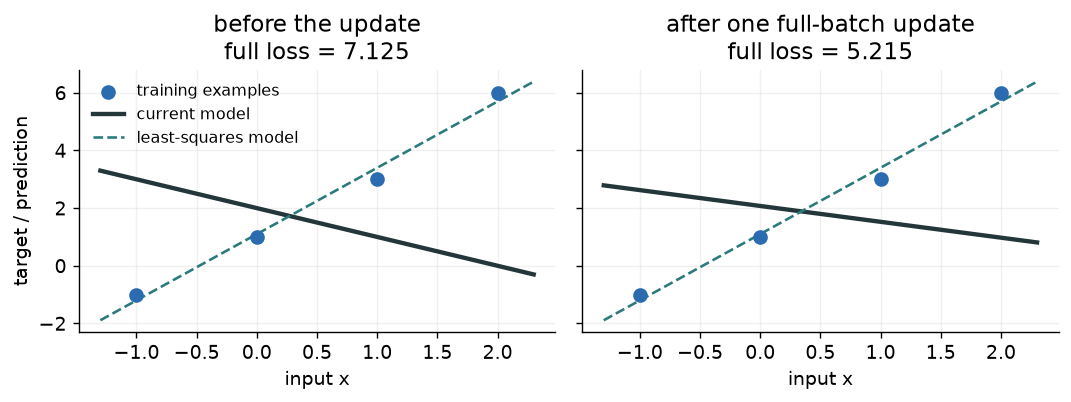

In [2]:
eta = 0.10
predictions = A @ theta0
residuals = predictions - y
losses0 = 0.5 * residuals**2
per_example_gradients = residuals[:, None] * A
g0 = per_example_gradients.mean(axis=0)
g_full = g0  # fixed Example A: exact full gradient at theta_0
theta_full = theta0 - eta * g_full

print(' i |    x |    y | y_hat | residual |  loss | gradient (db, dw)')
print('-' * 70)
for i, (xi, yi, yhat, ri, li, gi) in enumerate(
    zip(x, y, predictions, residuals, losses0, per_example_gradients), start=1
):
    print(f'{i:2d} | {xi:4.0f} | {yi:4.0f} | {yhat:5.1f} | {ri:8.1f} | '
          f'{li:5.1f} | ({gi[0]:5.1f}, {gi[1]:5.1f})')

print(f'\nL(theta0) = ({" + ".join(f"{v:.1f}" for v in losses0)}) / 4 = {loss(theta0):.3f}')
print('g_full   = mean of the four gradients =', g_full)
print('theta1   = theta0 - 0.10 g_full      =', theta_full)
print(f'L(theta1): {loss(theta0):.3f} -> {loss(theta_full):.3f}')

assert np.allclose(predictions, [3., 2., 1., 0.])
assert np.allclose(per_example_gradients,
                   [[4., -4.], [1., 0.], [-2., -2.], [-6., -12.]])
assert np.allclose(g_full, [-0.75, -4.5])
assert np.allclose(theta_full, [2.075, -0.55])
assert np.isclose(loss(theta0), 7.125)
assert loss(theta_full) < loss(theta0)

xx = np.linspace(-1.3, 2.3, 120)
fig, axes = plt.subplots(1, 2, figsize=(8.7, 3.35), sharex=True, sharey=True)
for ax, theta, title in zip(
    axes, [theta0, theta_full], ['before the update', 'after one full-batch update']
):
    ax.scatter(x, y, s=55, color=BLUE, zorder=3, label='training examples')
    ax.plot(xx, theta[0] + theta[1] * xx, color=INK, lw=2.5, label='current model')
    ax.plot(xx, theta_star[0] + theta_star[1] * xx, '--', color=TEAL,
            label='least-squares model')
    ax.set(title=f'{title}\nfull loss = {loss(theta):.3f}', xlabel='input x')
axes[0].set_ylabel('target / prediction')
axes[0].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

## 2. Each example defines its own loss surface

A full-batch update must read all $N$ examples before changing the parameters. SGD asks whether we can update sooner by randomly selecting just one example.

For Example A, the four component losses are

$$\begin{aligned}
\ell_1(b,w)&=\tfrac12(b-w+1)^2, &
\ell_2(b,w)&=\tfrac12(b-1)^2,\\
\ell_3(b,w)&=\tfrac12(b+w-3)^2, &
\ell_4(b,w)&=\tfrac12(b+2w-6)^2.
\end{aligned}$$

Their average is the full loss $\mathcal L=\tfrac14(\ell_1+\ell_2+\ell_3+\ell_4)$. A one-example SGD update differentiates one randomly selected $\ell_i$, not the full average.

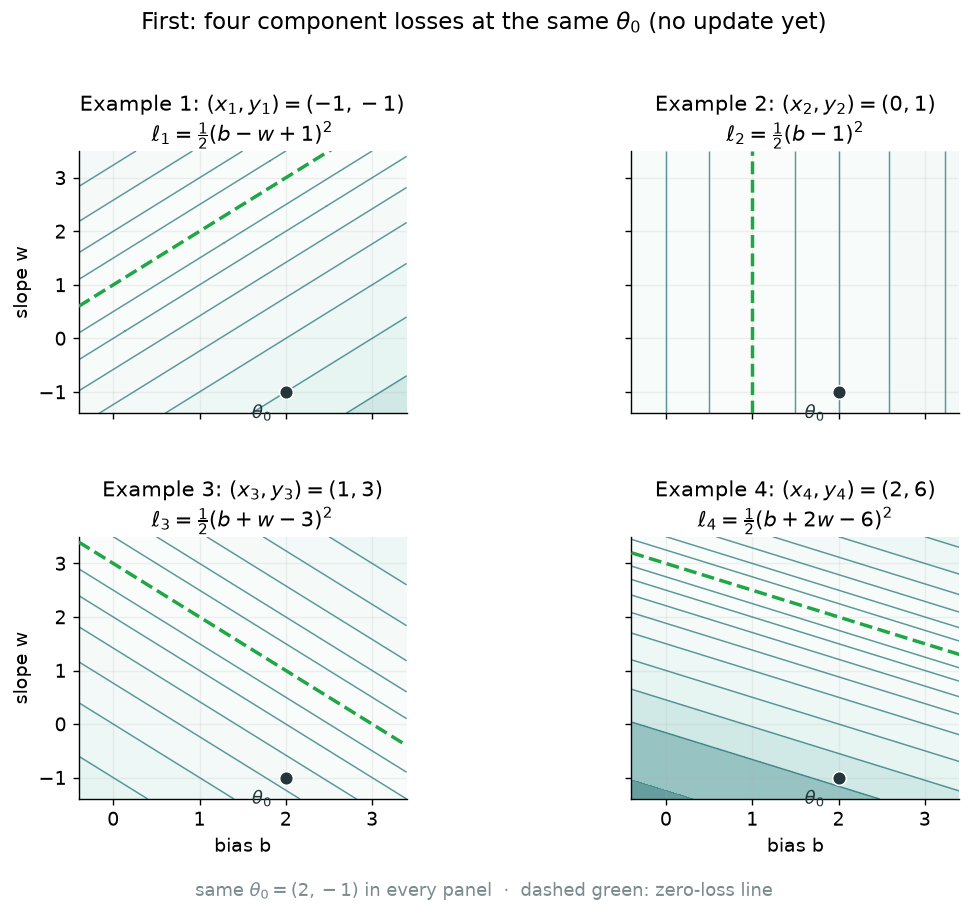

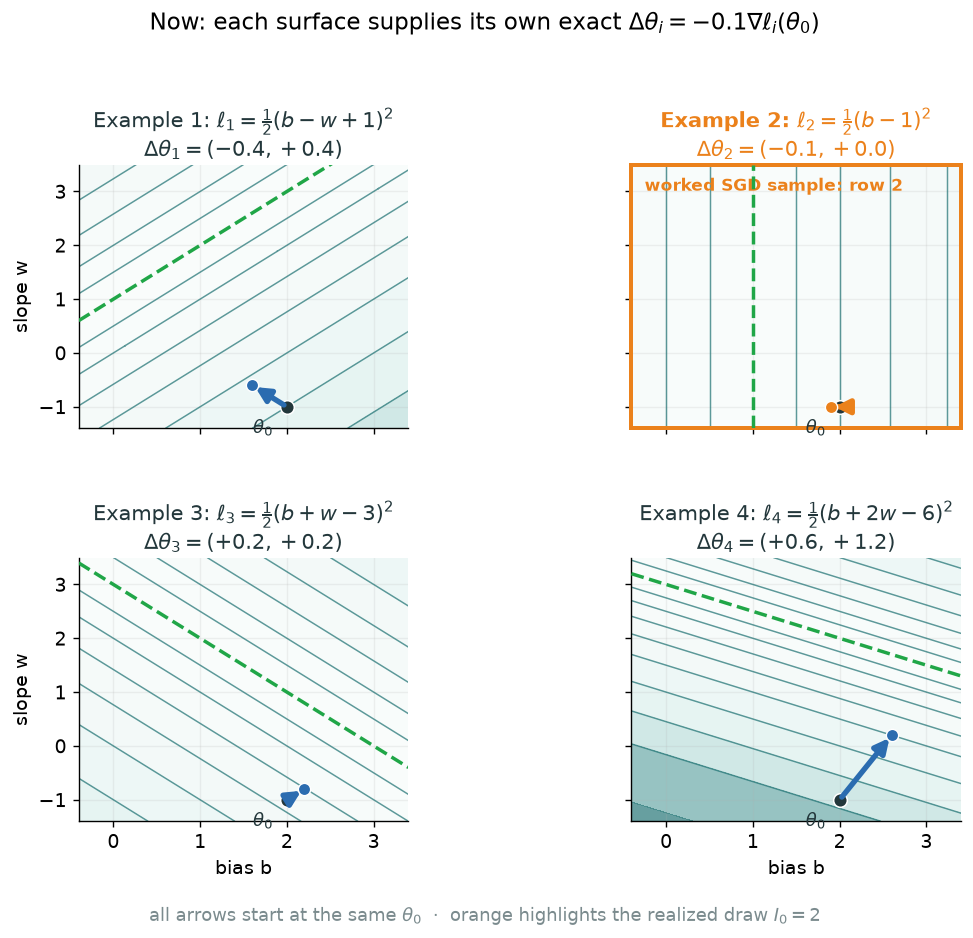

In [3]:
from matplotlib.colors import LinearSegmentedColormap

# Match the deck's shared parameter-space window.
b_values = np.linspace(-0.40, 3.40, 320)
w_values = np.linspace(-1.40, 3.50, 320)
B_MESH, W_MESH = np.meshgrid(b_values, w_values)
contour_levels = [0.125, 0.5, 1.25, 2.5, 4.5, 8.0, 13.0, 20.0]
surface_cmap = LinearSegmentedColormap.from_list(
    'example_a_surface', ['#F7FBFA', '#D9EFEC', '#91C8C4', TEAL]
)
equations = [
    r'$\ell_1=\frac{1}{2}(b-w+1)^2$',
    r'$\ell_2=\frac{1}{2}(b-1)^2$',
    r'$\ell_3=\frac{1}{2}(b+w-3)^2$',
    r'$\ell_4=\frac{1}{2}(b+2w-6)^2$',
]
sampled_index = 1  # zero-based: row/example 2 is (x, y) = (0, 1)


def draw_individual_surface(ax, i):
    individual_loss = 0.5 * (B_MESH + W_MESH * x[i] - y[i])**2
    ax.contourf(
        B_MESH, W_MESH, individual_loss,
        levels=[0.0, *contour_levels, 36.0], cmap=surface_cmap,
        extend='max', alpha=0.72,
    )
    ax.contour(
        B_MESH, W_MESH, individual_loss, levels=contour_levels,
        colors=TEAL, alpha=0.76, linewidths=0.86,
    )

    # Dashed green: every (b, w) that fits this one example exactly.
    if x[i] == 0:
        ax.axvline(y[i], color='#20A647', ls='--', lw=2.0, zorder=7)
    else:
        ax.plot(b_values, (y[i] - b_values) / x[i], '--',
                color='#20A647', lw=2.0, zorder=7)

    ax.scatter(*theta0, s=62, color=INK, edgecolor='white', linewidth=.9, zorder=10)
    ax.annotate(r'$\theta_0$', xy=theta0, xytext=(-8, -15),
                textcoords='offset points', ha='right', color=INK,
                fontsize=10.5, fontweight='bold', zorder=11)
    ax.set(xlim=(-0.40, 3.40), ylim=(-1.40, 3.50),
           xticks=[0, 1, 2, 3], yticks=[-1, 0, 1, 2, 3])
    ax.set_box_aspect(.80)


# Reveal A: first understand the four objectives. Deliberately no arrows.
fig, axes = plt.subplots(2, 2, figsize=(9.3, 7.2), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    draw_individual_surface(ax, i)
    ax.set_title(
        f'Example {i + 1}: $(x_{i+1},y_{i+1})=({x[i]:.0f},{y[i]:.0f})$\n' + equations[i],
        fontsize=12.3, pad=5,
    )
for ax in axes[-1]: ax.set_xlabel('bias b')
for ax in axes[:, 0]: ax.set_ylabel('slope w')
fig.suptitle(r'First: four component losses at the same $\theta_0$ (no update yet)', y=.995)
fig.text(.5, .012,
         r'same $\theta_0=(2,-1)$ in every panel  ·  dashed green: zero-loss line',
         ha='center', color=MUTED, fontsize=10.3)
fig.subplots_adjust(left=.08, right=.98, bottom=.12, top=.84, wspace=.12, hspace=.47)
plt.show()

# Reveal B: differentiate each displayed surface and add its exact parameter update.
updates = -eta * per_example_gradients
expected_updates = np.array([[-.4, .4], [-.1, 0.], [.2, .2], [.6, 1.2]])
assert np.allclose(updates, expected_updates)

fig, axes = plt.subplots(2, 2, figsize=(9.3, 7.4), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    draw_individual_surface(ax, i)
    endpoint = theta0 + updates[i]
    highlighted = i == sampled_index
    color = ORANGE if highlighted else BLUE
    ax.annotate('', xy=endpoint, xytext=theta0,
                arrowprops=dict(arrowstyle='-|>', color=color, lw=3.1,
                                mutation_scale=17), zorder=12)
    ax.scatter(*endpoint, s=50, color=color, edgecolor='white', linewidth=.8, zorder=13)
    delta = np.where(np.isclose(updates[i], 0.0), 0.0, updates[i])
    delta_text = rf'$\Delta\theta_{i+1}=({delta[0]:+.1f},{delta[1]:+.1f})$'
    ax.set_title(
        f'Example {i + 1}: ' + equations[i] + '\n' + delta_text,
        fontsize=12.0, pad=5, color=color if highlighted else INK,
        fontweight='bold' if highlighted else 'normal',
    )
    if highlighted:
        for spine in ax.spines.values():
            spine.set_visible(True); spine.set_color(ORANGE); spine.set_linewidth(2.3)
        ax.text(.04, .95, 'worked SGD sample: row 2', transform=ax.transAxes,
                va='top', color=ORANGE, fontsize=9.7, fontweight='bold')

for ax in axes[-1]: ax.set_xlabel('bias b')
for ax in axes[:, 0]: ax.set_ylabel('slope w')
fig.suptitle(r'Now: each surface supplies its own exact $\Delta\theta_i=-0.1\nabla\ell_i(\theta_0)$',
             y=.995)
fig.text(.5, .012,
         r'all arrows start at the same $\theta_0$  ·  orange highlights the realized draw $I_0=2$',
         ha='center', color=MUTED, fontsize=10.3)
fig.subplots_adjust(left=.08, right=.98, bottom=.12, top=.83, wspace=.12, hspace=.49)
plt.show()

## 3. One sampled SGD update

**Stochastic** means that the update contains an explicit random choice. At iteration $t$:

$$I_t\sim\operatorname{Uniform}\{1,\ldots,N\},\qquad
\widehat{\boldsymbol g}_t=\nabla\ell_{I_t}(\boldsymbol\theta_t),\qquad
\boldsymbol\theta_{t+1}=\boldsymbol\theta_t-\eta\widehat{\boldsymbol g}_t.$$

Suppose the realized draw is $I_0=2$, the orange panel above. Then

$$\widehat y_2=2+(-1)(0)=2,\quad e_2=2-1=1,\quad
\widehat{\boldsymbol g}_0=1\begin{bmatrix}1\\0\end{bmatrix}
=\begin{bmatrix}1\\0\end{bmatrix},$$

$$\boldsymbol\theta_1=
\begin{bmatrix}2\\-1\end{bmatrix}
-0.1\begin{bmatrix}1\\0\end{bmatrix}
=\begin{bmatrix}1.9\\-1\end{bmatrix}.$$

This is one valid random realization. The other three examples would have proposed different updates.

## 4. The stochastic gradient is an unbiased estimator

### Start with expectation

If $X$ is a discrete random variable with support $\mathcal X$ and probability mass $p(x)=\Pr(X=x)$, then for any function $f$,

$$\mathbb E[f(X)]=\sum_{x\in\mathcal X}p(x)f(x).$$

For a continuous random variable, the corresponding expectation uses an integral rather than a sum.

### Then define unbiasedness

If $q$ is the target quantity and $\widehat q(X)$ is a random estimate, the estimator is **unbiased** when

$$\mathbb E[\widehat q(X)]=q.$$

### Substitute the stochastic-gradient objects

At update $t$, hold $\boldsymbol\theta_t$ fixed—formally, condition on the training history before drawing the next index. For fresh uniform sampling, set

$$X=I_t,\qquad p(i)=\Pr(I_t=i)=\frac1N,\qquad f(i)=\nabla_{\boldsymbol\theta}\ell_i(\boldsymbol\theta_t),$$

and define the random gradient estimate

$$\widehat{\boldsymbol g}_t=f(I_t)=\nabla_{\boldsymbol\theta}\ell_{I_t}(\boldsymbol\theta_t).$$

Now the generic expectation rule gives the general proof:

$$\begin{aligned}
\mathbb E[\widehat{\boldsymbol g}_t\mid\text{history before }I_t]
&=\sum_{i=1}^N \Pr(I_t=i)\,f(i)\\
&=\frac1N\sum_{i=1}^N\nabla_{\boldsymbol\theta}\ell_i(\boldsymbol\theta_t)\\
&=\nabla_{\boldsymbol\theta}\mathcal L(\boldsymbol\theta_t)
=\boldsymbol g_t.
\end{aligned}$$

For Example A, $N=4$ and $\boldsymbol\theta_t=\boldsymbol\theta_0$, so the same calculation becomes

$$\begin{aligned}
\mathbb E_{I_0}[\widehat{\boldsymbol g}_0]
&=\frac14\left[
\begin{pmatrix}4\\-4\end{pmatrix}+
\begin{pmatrix}1\\0\end{pmatrix}+
\begin{pmatrix}-2\\-2\end{pmatrix}+
\begin{pmatrix}-6\\-12\end{pmatrix}\right]\\
&=\begin{pmatrix}-0.75\\-4.5\end{pmatrix}
=\boldsymbol g_0=\boldsymbol g_{\text{full}}.
\end{aligned}$$

The conditioning and uniform sampling rule are essential. Unbiased means that repeated estimates are centred on the full gradient at the fixed current parameters; it does **not** mean every sampled gradient is correct by itself, or that every stochastic update lowers the full loss.

exact full gradient:        [-0.75 -4.5 ]
mean of 20,000 SGD draws: [-0.7439 -4.5297]


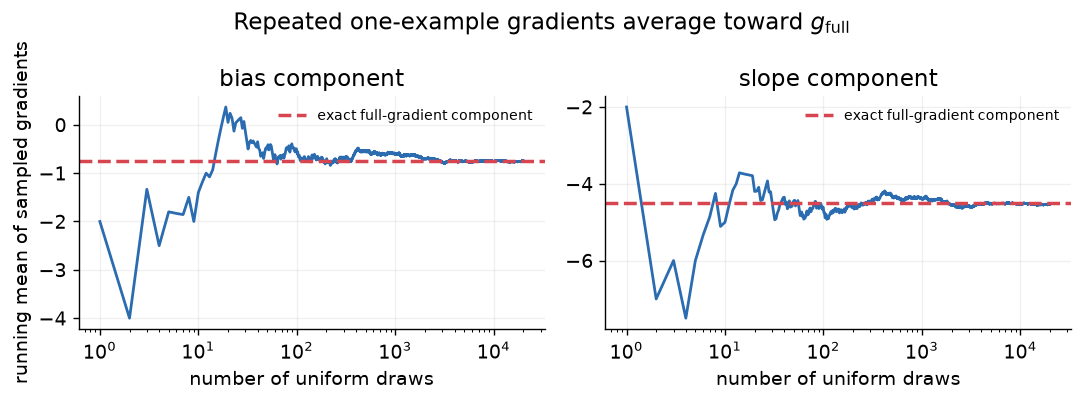

In [4]:
# Empirical check: repeatedly draw one index uniformly at the same fixed theta0.
rng = np.random.default_rng(SEED)
draws = rng.integers(0, len(x), size=20_000)
sampled_gradients = per_example_gradients[draws]
empirical_mean = sampled_gradients.mean(axis=0)
running_mean = np.cumsum(sampled_gradients, axis=0) / np.arange(1, len(draws) + 1)[:, None]

print('exact full gradient:       ', g_full)
print('mean of 20,000 SGD draws:', np.round(empirical_mean, 4))
assert np.allclose(empirical_mean, g_full, atol=0.08)

fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.25), sharex=True)
labels = ['bias component', 'slope component']
for j, ax in enumerate(axes):
    ax.plot(np.arange(1, len(draws) + 1), running_mean[:, j], color=BLUE, lw=1.6)
    ax.axhline(g_full[j], color=RED, ls='--', lw=2,
               label='exact full-gradient component')
    ax.set_xscale('log')
    ax.set(title=labels[j], xlabel='number of uniform draws')
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel('running mean of sampled gradients')
fig.suptitle(r'Repeated one-example gradients average toward $g_{\rm full}$')
plt.tight_layout(); plt.show()

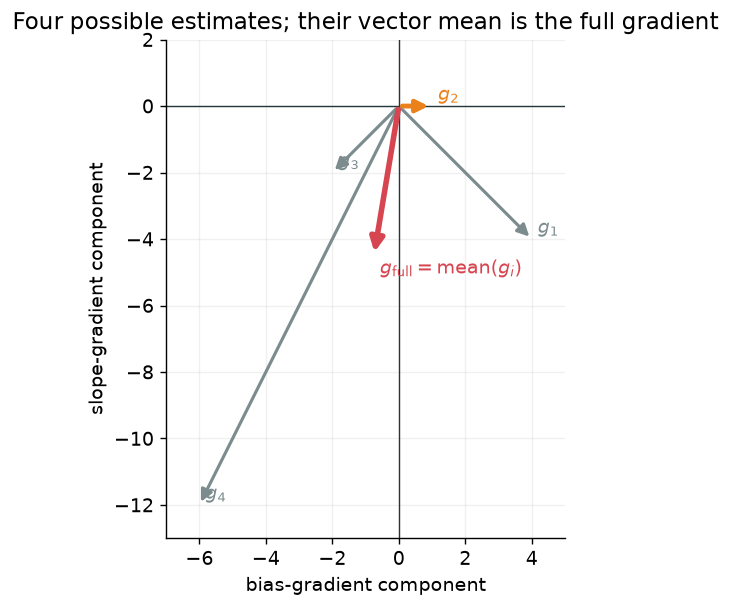

In [5]:
# The exact vector picture behind the expectation calculation.
fig, ax = plt.subplots(figsize=(6.0, 5.0))
for i, g_i in enumerate(per_example_gradients):
    chosen = i == sampled_index
    color = ORANGE if chosen else MUTED
    ax.annotate('', xy=g_i, xytext=(0, 0),
                arrowprops=dict(arrowstyle='-|>', color=color,
                                lw=2.8 if chosen else 1.8, mutation_scale=14))
    ax.text(g_i[0] + .18, g_i[1] + .18, fr'$g_{i+1}$', color=color)
ax.annotate('', xy=g_full, xytext=(0, 0),
            arrowprops=dict(arrowstyle='-|>', color=RED, lw=3.2, mutation_scale=16))
ax.text(g_full[0] + .18, g_full[1] - .55, r'$g_{\rm full}=\operatorname{mean}(g_i)$',
        color=RED, fontweight='bold')
ax.axhline(0, color=INK, lw=.8); ax.axvline(0, color=INK, lw=.8)
ax.set(xlabel='bias-gradient component', ylabel='slope-gradient component',
       title='Four possible estimates; their vector mean is the full gradient',
       xlim=(-7, 5), ylim=(-13, 2), aspect='equal')
plt.tight_layout(); plt.show()

## 5. Minibatches preserve the mean and reduce spread

A size-$B$ minibatch averages several example gradients:

$$\widehat{\boldsymbol g}_{\mathcal B,t}
=\frac1B\sum_{i\in\mathcal B}\nabla_{\boldsymbol\theta}\ell_i(\boldsymbol\theta_t).$$

If $\mathcal B$ is selected uniformly, linearity of expectation keeps the same centre:

$$\mathbb E[\widehat{\boldsymbol g}_{\mathcal B,t}\mid\boldsymbol\theta_t]
=\boldsymbol g_t.$$

Why is it less noisy? A single unusual example can pull strongly. In an average, some disagreements cancel. Below we enumerate every possible uniform subset at the **same** $\boldsymbol\theta_0$; these are $\widehat{\boldsymbol g}_{\mathcal B,0}$ estimates centred on $\boldsymbol g_0=\boldsymbol g_{\text{full}}$, and no training updates occur in this comparison.

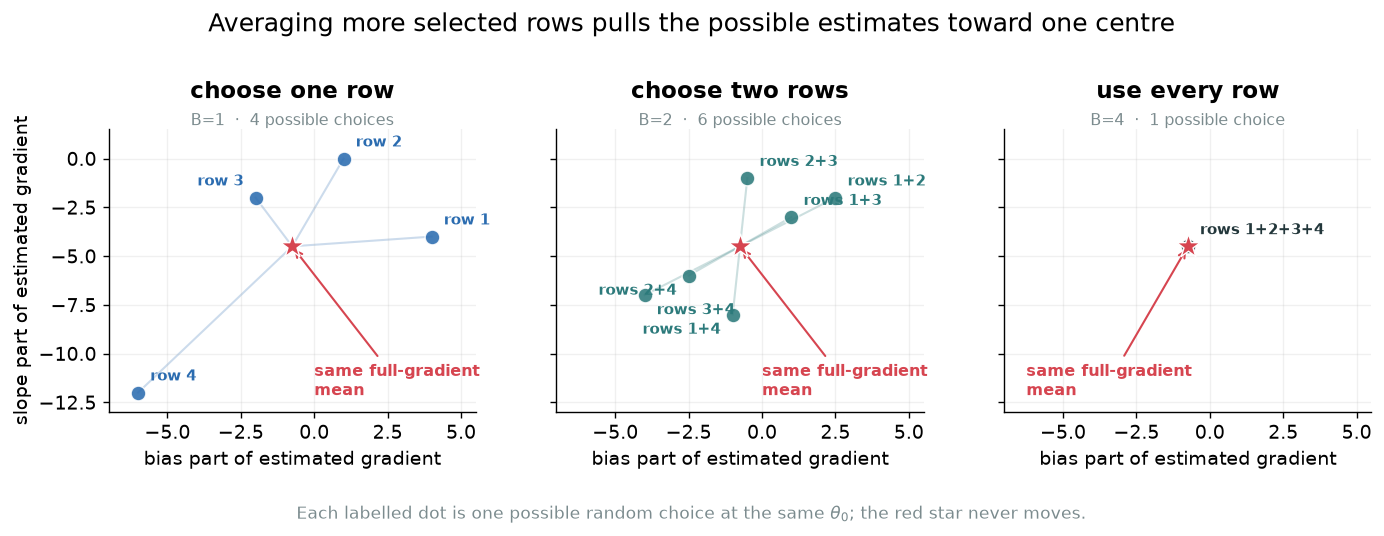

 B | possible subsets | mean estimate        | RMS distance from full gradient
------------------------------------------------------------------------------
 1 |                4 | [-0.75 -4.5 ]        |    5.868
 2 |                6 | [-0.75 -4.5 ]        |    3.388
 4 |                1 | [-0.75 -4.5 ]        |    0.000


In [6]:
def all_subset_gradients(batch_size):
    batches = list(itertools.combinations(range(len(x)), batch_size))
    estimates = np.stack([grad(theta0, batch) for batch in batches])
    return batches, estimates

panel_titles = {1: 'choose one row', 2: 'choose two rows', 4: 'use every row'}

def row_label(batch):
    rows = [str(i + 1) for i in batch]
    return ('row ' if len(rows) == 1 else 'rows ') + '+'.join(rows)

summaries = []
fig, axes = plt.subplots(1, 3, figsize=(11.1, 3.9), sharex=True, sharey=True)
for ax, B, color in zip(axes, [1, 2, 4], [BLUE, TEAL, INK]):
    batches, estimates = all_subset_gradients(B)
    mean_estimate = estimates.mean(axis=0)
    rms_distance = np.sqrt(np.mean(np.sum((estimates - g_full)**2, axis=1)))
    summaries.append((B, len(estimates), mean_estimate, rms_distance))
    for batch, estimate in zip(batches, estimates):
        # The pale spoke makes 'spread from the shared centre' visible.
        ax.plot([g_full[0], estimate[0]], [g_full[1], estimate[1]],
                color=color, alpha=.24, lw=1.2, zorder=1)
        ax.scatter(*estimate, s=72, color=color, alpha=.88,
                   edgecolor='white', linewidth=.8, zorder=2)
        # Keep labels inside the shared plotting window at either extreme.
        if estimate[0] < -3.5:
            dx = 7
        elif estimate[0] > 4.5:
            dx = -7
        else:
            dx = 7 if estimate[0] >= g_full[0] else -7
        if estimate[1] < -11.0:
            dy = 7
        else:
            dy = 7 if estimate[1] >= g_full[1] else -11
        ax.annotate(row_label(batch), xy=estimate, xytext=(dx, dy),
                    textcoords='offset points',
                    ha='left' if dx > 0 else 'right',
                    fontsize=8.8, color=color, fontweight='bold')

    ax.scatter(*g_full, marker='*', s=205, color=RED,
               edgecolor='white', linewidth=.8, zorder=4)
    mean_label_position = (.56, .06) if B in (1, 2) else (.06, .06)
    ax.annotate('same full-gradient\nmean', xy=g_full, xycoords='data',
                xytext=mean_label_position, textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color=RED, lw=1.2),
                color=RED, fontsize=9.2, fontweight='bold')
    choice_word = 'choice' if len(estimates) == 1 else 'choices'
    ax.set_title(panel_titles[B], fontsize=13, fontweight='bold', pad=18)
    ax.text(.5, 1.015, f'B={B}  ·  {len(estimates)} possible {choice_word}',
            transform=ax.transAxes, ha='center', color=MUTED, fontsize=9.4)
    ax.set(xlabel='bias part of estimated gradient',
           xlim=(-7.0, 5.5), ylim=(-13.0, 1.5))
axes[0].set_ylabel('slope part of estimated gradient')
fig.suptitle('Averaging more selected rows pulls the possible estimates toward one centre',
             fontsize=14.2, y=1.02)
fig.text(.5, -.02,
         r'Each labelled dot is one possible random choice at the same $\theta_0$; the red star never moves.',
         ha='center', color=MUTED, fontsize=10)
fig.subplots_adjust(left=.08, right=.99, bottom=.20, top=.78, wspace=.22)
plt.show()

print(' B | possible subsets | mean estimate        | RMS distance from full gradient')
print('-' * 78)
for B, count, mean_estimate, rms_distance in summaries:
    print(f'{B:2d} | {count:16d} | {str(np.round(mean_estimate, 3)):20s} | {rms_distance:8.3f}')

assert all(np.allclose(row[2], g_full) for row in summaries)
assert summaries[0][3] > summaries[1][3] > summaries[2][3]

## 6. One valid stochastic step need not lower the full loss

Unbiasedness is an average-over-random-draws statement. It does **not** promise that each sampled gradient is close to $\boldsymbol g_{\text{full}}$, or that each update lowers $\mathcal L$.

Return to the realized sample $I_0=2$. Its own loss must initially fall for a sufficiently small step in its negative-gradient direction. But $b$ is shared by all four examples, so the update also changes the other three losses. We must recompute their average.

sampled example: i=2, (x, y)=(0, 1)
sampled gradient: [1. 0.] -> theta1: [ 1.9 -1. ]
sampled loss ell_2: 0.500 -> 0.405
L(theta0) = (8.000 + 0.500 + 2.000 + 18.000) / 4 = 7.125
L(theta1) = (7.605 + 0.405 + 2.205 + 18.605) / 4 = 7.205
full-loss change = +0.080


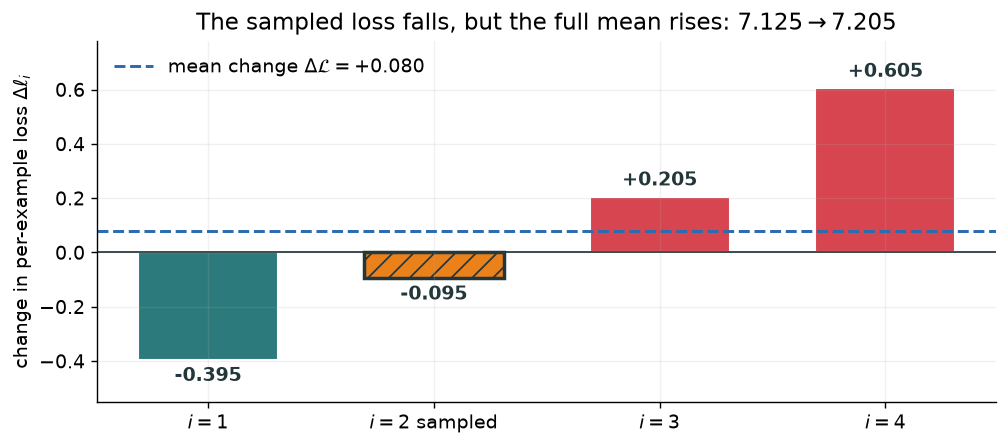

In [7]:
i = sampled_index
g_sample = per_example_gradients[i]
theta_sgd = theta0 - eta * g_sample
before = per_example_losses(theta0)
after = per_example_losses(theta_sgd)
changes = after - before

print('sampled example: i=2, (x, y)=(0, 1)')
print('sampled gradient:', g_sample, '-> theta1:', theta_sgd)
print(f'sampled loss ell_2: {before[i]:.3f} -> {after[i]:.3f}')
print(f'L(theta0) = ({" + ".join(f"{v:.3f}" for v in before)}) / 4 = {before.mean():.3f}')
print(f'L(theta1) = ({" + ".join(f"{v:.3f}" for v in after)}) / 4 = {after.mean():.3f}')
print(f'full-loss change = {after.mean() - before.mean():+.3f}')

assert np.allclose(theta_sgd, [1.9, -1.0])
assert after[i] < before[i]
assert np.isclose(before.mean(), 7.125)
assert np.isclose(after.mean(), 7.205)

labels = [r'$i=1$', r'$i=2$ sampled', r'$i=3$', r'$i=4$']
colors = [TEAL, ORANGE, RED, RED]
fig, ax = plt.subplots(figsize=(8.2, 3.7))
bars = ax.bar(labels, changes, color=colors, width=.62,
              edgecolor='white', linewidth=1.2)
bars[i].set_edgecolor(INK); bars[i].set_linewidth(2); bars[i].set_hatch('//')
ax.axhline(0, color=INK, lw=1.0)
ax.axhline(changes.mean(), color=BLUE, ls='--', lw=1.7,
           label=fr'mean change $\Delta\mathcal{{L}}={changes.mean():+.3f}$')
for bar, value in zip(bars, changes):
    ax.text(bar.get_x() + bar.get_width()/2, value + (.025 if value >= 0 else -.025),
            f'{value:+.3f}', ha='center',
            va='bottom' if value >= 0 else 'top', color=INK, fontweight='bold')
ax.set(ylabel=r'change in per-example loss $\Delta\ell_i$',
       title=r'The sampled loss falls, but the full mean rises: $7.125\to7.205$',
       ylim=(-.55, .78))
ax.legend(frameon=False, loc='upper left')
plt.tight_layout(); plt.show()

## 7. Batch, iteration, update, and epoch

- **Batch size $B$:** examples used to form one gradient estimate.
- **Iteration:** one pass through the training-loop body for one minibatch.
- **Optimizer update:** one call to `optimizer.step()` that changes parameters.
- **Epoch:** one pass through the $N$ training examples.

In the simple loop used here, each iteration causes one optimizer update. With gradient accumulation, several iterations may feed one update.

For $N=4$ and no dropped final batch:

| method | batch size | iterations / updates per epoch |
|---|---:|---:|
| batch GD | $B=4$ | 1 |
| minibatch SGD | $B=2$ | 2 |
| one-example SGD | $B=1$ | 4 |

In general, iterations per epoch are $\lceil N/B\rceil$. Different update counts are one reason that learning-rate and speed comparisons must state what is being held fixed.

In [8]:
order = np.array([2, 0, 3, 1])  # one deterministic shuffled epoch (zero-based)
for B in [4, 2, 1]:
    batches = [order[start:start+B] for start in range(0, len(order), B)]
    one_based = [[int(i + 1) for i in batch] for batch in batches]
    print(f'B={B}: {len(batches)} iteration(s) / update(s), batches = {one_based}')
    assert len(batches) == int(np.ceil(len(x) / B))

B=4: 1 iteration(s) / update(s), batches = [[3, 1, 4, 2]]
B=2: 2 iteration(s) / update(s), batches = [[3, 1], [4, 2]]
B=1: 4 iteration(s) / update(s), batches = [[3], [1], [4], [2]]


## Optional: sampling details beyond the core story

The unbiasedness statement always belongs with a sampling rule.

- **Fresh uniform index:** the proof above applies directly at fixed $\boldsymbol\theta_t$.
- **Random reshuffling:** common in practice, but later draws within an epoch depend on which examples have already appeared. Do not describe every within-epoch draw as an independent fresh sample.
- **Nonuniform probabilities $p_i$:** the unweighted mean is generally biased. The importance-weighted estimate $\nabla\ell_I/(N p_I)$ restores the full-gradient expectation when every $p_i>0$.
- **Spread formulas:** for $B$ independent draws with replacement, averaging divides the covariance by $B$. Uniform sampling without replacement is tighter still; when $B=N$, it is exactly the full gradient.

These details matter when implementing custom samplers, but they are not needed to understand the main batch–SGD–minibatch progression.

In [9]:
# Optional exact check for a deliberately nonuniform sampler.
probabilities = np.array([0.55, 0.15, 0.15, 0.15])
unweighted_expectation = np.sum(probabilities[:, None] * per_example_gradients, axis=0)
importance_weighted = per_example_gradients / (len(x) * probabilities[:, None])
corrected_expectation = np.sum(probabilities[:, None] * importance_weighted, axis=0)

print('full gradient:                         ', g_full)
print('nonuniform, unweighted expectation:   ', unweighted_expectation)
print('nonuniform, importance-weighted mean: ', corrected_expectation)

assert not np.allclose(unweighted_expectation, g_full)
assert np.allclose(corrected_expectation, g_full)

full gradient:                          [-0.75 -4.5 ]
nonuniform, unweighted expectation:    [ 1.15 -4.3 ]
nonuniform, importance-weighted mean:  [-0.75 -4.5 ]


## 8. The same mechanics in PyTorch

`DataLoader(..., batch_size=B)` selects how many examples build each loss. Autograd differentiates that batch mean, and `optimizer.step()` applies one parameter update.

First verify that a full batch reproduces the analytical gradient. Then run a small deterministic $B=2$ loop. We keep the factor $\tfrac12$ so the PyTorch loss matches the half-MSE convention used above.

In [10]:
features = torch.tensor(A, dtype=torch.float64)  # each row is [1, x_i]
targets = torch.tensor(y, dtype=torch.float64)
full_loader = DataLoader(TensorDataset(features, targets), batch_size=4, shuffle=False)

theta_torch = torch.tensor(theta0, dtype=torch.float64, requires_grad=True)
xb, yb = next(iter(full_loader))
batch_loss = 0.5 * ((xb @ theta_torch - yb)**2).mean()
batch_loss.backward()

print('autograd full-batch gradient:', theta_torch.grad.numpy())
print('analytical full gradient:     ', g_full)
assert np.allclose(theta_torch.grad.numpy(), g_full, atol=1e-12)

autograd full-batch gradient: [-0.75 -4.5 ]
analytical full gradient:      [-0.75 -4.5 ]


In [11]:
generator = torch.Generator().manual_seed(SEED)
loader = DataLoader(
    TensorDataset(features, targets), batch_size=2, shuffle=True, generator=generator
)
theta_torch = torch.nn.Parameter(torch.tensor(theta0, dtype=torch.float64))
optimizer = torch.optim.SGD([theta_torch], lr=0.05)

updates = 0
for epoch in range(80):
    for xb, yb in loader:                 # one iteration / minibatch
        optimizer.zero_grad(set_to_none=True)
        predictions_b = xb @ theta_torch
        batch_loss = 0.5 * ((predictions_b - yb)**2).mean()
        batch_loss.backward()              # gradient of this batch mean
        optimizer.step()                   # one parameter update
        updates += 1

learned = theta_torch.detach().numpy()
print(f'80 epochs x 2 minibatches = {updates} updates')
print('learned theta:', np.round(learned, 4))
print('least-squares theta:', theta_star)
print('final full loss:', loss(learned))

assert updates == 160
assert loss(learned) < 0.08

80 epochs x 2 minibatches = 160 updates
learned theta: [1.1072 2.2952]
least-squares theta: [1.1 2.3]
final full loss: 0.037526003377633614


## Takeaways

1. The full-data gradient is the average of the per-example gradients.
2. SGD is stochastic because it randomly selects which example supplies the next gradient.
3. With a uniform sampler and fixed current parameters, the one-example gradient is an unbiased estimator of the exact empirical gradient.
4. Uniform minibatch averages keep that same mean while reducing estimator spread.
5. Unbiased does **not** mean exact, downhill on every draw, or guaranteed to converge.
6. Batch size changes the number of iterations and optimizer updates in an epoch; comparisons must state which clock and learning-rate convention they use.

Next: momentum uses an exponentially weighted moving average to reduce unhelpful oscillation while retaining consistent motion.